In [1]:
import pandas as pd
import numpy as np
import re
from sentence_transformers import SentenceTransformer
from tqdm import tqdm

/Users/josepomarino/Desktop/Data Projects/song_lyrics/venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
df = pd.read_json("../data/filtered_songs.json")

In [3]:
print(df["artist"].value_counts())        
print(df.isnull().sum())                 
print(df["lyrics"].str.len().describe()) 

artist
Carly Rae Jepsen     142
Sabrina Carpenter    112
Billie Eilish         73
Olivia Rodrigo        68
Maggie Rogers         68
Maisie Peters         67
Lorde                 58
Holly Humberstone     52
Reneé Rapp            48
Addison Rae           20
Audrey Hobert         13
Name: count, dtype: int64
artist           0
title            0
album           27
release_date    53
lyrics           0
dtype: int64
count     721.000000
mean     1518.079057
std       485.696414
min       167.000000
25%      1196.000000
50%      1538.000000
75%      1825.000000
max      3234.000000
Name: lyrics, dtype: float64


In [4]:
# Define list of filler words
FILLER_WORDS = {
    "yeah", "yea", "oh", "uh", "ah", "ooh", "ayy", "ay", "ya",
    "na", "la", "woah", "whoa", "huh", "mm", "mmm"
}

def clean_text(text: str) -> str:
    
    if not isinstance(text, str):
        return ""
    
    text = re.sub(r"\[.*?\]", "", text)        # remove [Verse 1], [Chorus] etc.
    text = re.sub(r"\s+", " ", text)           # collapse multiple whitespace
    return text.strip()

In [5]:
preprocessed_lyrics = df["lyrics"].apply(clean_text)

In [6]:
preprocessed_lyrics

0      I know I have good judgment, I know I have goo...
1      (Ooh, ah-ah, ooh) Don't have to tell your hot ...
2      Oh boy You said your phone was broken, just fo...
3      I was in a sheer dress the day that we met We ...
4      Now he's thinkin' 'bout me every night, oh Is ...
                             ...                        
716    Excuse me for a minute 'Cause this won't be br...
717    The forest is dark and I'm wide awake, not sle...
718    Well, I've lived a short life Not a lot of thi...
719    You, you, you, you You, you, you, you You, you...
720    Vers 1: Feeling like the wind Blowing in my fa...
Name: lyrics, Length: 721, dtype: str

In [7]:
MAX_WORDS_PER_CHUNK = 200
CHUNK_OVERLAP = 30

def chunk_lyrics(lyrics: str, max_words: int = MAX_WORDS_PER_CHUNK, overlap: int = CHUNK_OVERLAP) -> list[str]:
    
    words = lyrics.split()
    
    if len(words) <= max_words:
        return words
    
    chunks = []
    start = 0
    
    while start < len(words):
        end = min(start + max_words, len(words))
        chunks.append(" ".join(words[start:end]))
        
        if end == len(words):
            break
        
        start += max_words - overlap
    
    return chunks
    

In [8]:
MODEL_NAME = "all-MiniLM-L6-v2"
EMBEDDING_DIM = 384

model = SentenceTransformer(MODEL_NAME)

Loading weights: 100%|██████████| 103/103 [00:00<00:00, 8657.06it/s]
BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [9]:
emb = model.encode(chunk_lyrics(preprocessed_lyrics[0])[0])

In [10]:
emb.shape

(384,)

In [11]:
def embed_song(lyrics: str, model = model, embedding_dim: int = EMBEDDING_DIM):
    
    # If the lyrics are not a string, or have no words: return zeros
    if not isinstance(lyrics, str) or len(lyrics.strip()) == 0:
        return np.zeros(embedding_dim)
    
    # Chunk the songs due to the model's token limit
    chunks = chunk_lyrics(lyrics)
    chunk_embeddings = model.encode(
        chunks,
        batch_size=32,
        show_progress_bar=False,
        convert_to_numpy=True,
        normalize_embeddings=True   # L2-normalize each chunk to normalize vector magnitudes for different sized chunks
    )
    
    # Average the chunks weighted by the length of the chunks
    word_counts = np.array([len(c.split()) for c in chunks], dtype = float)
    weights = word_counts / word_counts.sum()
    averaged = np.average(chunk_embeddings, axis = 0, weights = weights)
    
    # Re-normalize the averaged vector
    norm = np.linalg.norm(averaged)
    if norm > 0:
        averaged = averaged / norm

    return averaged

In [12]:
embeddings = np.zeros((len(df), EMBEDDING_DIM), dtype=np.float32)

for i, lyrics in enumerate(tqdm(preprocessed_lyrics, desc="Embedding")):
    embeddings[i] = embed_song(lyrics, model)

Embedding: 100%|██████████| 721/721 [00:18<00:00, 39.17it/s]


In [19]:
import umap
import matplotlib.pyplot as plt

reducer = umap.UMAP(n_neighbors=10)
umap_embedding = reducer.fit_transform(embeddings)
umap_embedding.shape

(721, 2)

Text(0.5, 1.0, 'UMAP projection of song lyrics')

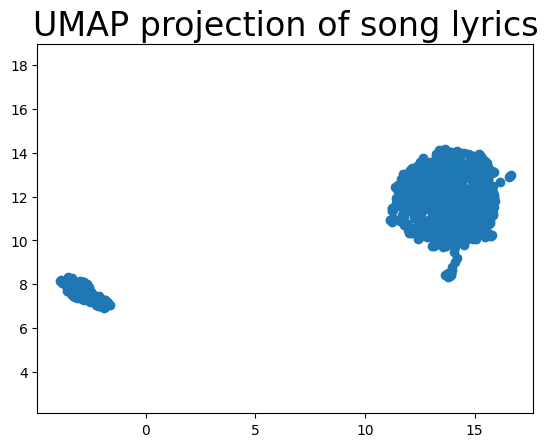

In [20]:
plt.scatter(
    umap_embedding[:, 0],
    umap_embedding[:, 1])
plt.gca().set_aspect('equal', 'datalim')
plt.title('UMAP projection of song lyrics', fontsize=24)

In [21]:
import plotly.express as px

# Build a plotting DataFrame
plot_df = pd.DataFrame({
    "UMAP 1":  umap_embedding[:, 0],
    "UMAP 2":  umap_embedding[:, 1],
    "artist":  df["artist"],
    "title":   df["title"],
    "album":   df["album"],
})

fig = px.scatter(
    plot_df,
    x="UMAP 1",
    y="UMAP 2",
    color="artist",
    hover_name="title",             # song title shown as bold header on hover
    hover_data={                    # additional info in hover tooltip
        "artist": True,
        "album":  True,
        "UMAP 1": ":.3f",
        "UMAP 2": ":.3f",
    },
    title="UMAP Projection of Song Lyrics — Colored by Artist",
    template="plotly_dark",         # clean dark background, swap to "plotly_white" if preferred
    opacity=0.8,
    size_max=8,
)

fig.update_traces(
    marker=dict(size=6, line=dict(width=0.5, color="white")),
    selector=dict(mode="markers")
)

fig.update_layout(
    width=1100,
    height=700,
    legend=dict(
        title="Artist",
        itemsizing="constant",
        bgcolor="rgba(0,0,0,0.3)",
        bordercolor="rgba(255,255,255,0.2)",
        borderwidth=1
    ),
    font=dict(size=12),
    title_font=dict(size=16),
    xaxis=dict(showgrid=False, zeroline=False),
    yaxis=dict(showgrid=False, zeroline=False),
)

fig.show()